<a href="https://colab.research.google.com/github/mundundan-star/online-retail-customer-analytics/blob/main/7.0%20Final_Delivery%3A%20Churn%20and%20CLTV%20Inference%20Pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#!pip install s3fs

### 1.0 INTRODUCTION
Having trained and validated `Segmentation`, `Churn`, and `CLTV` predictive models on data before `2011-08-31`, this notebook serves as the inference backend, making predictions on customer data without known outcomes, currently data after `2011-08-31`, as it would be expected when deployed.

#### 1.1 Extract, Load and Transform (ETL) Pipeline
- The `data engineering notebook` receives unclean data as it would be captured during data entry, stored in an AWS S3 datalake as an Excel file, loads it into a dataframe, upon which a data cleaning function created in the `data engineering` notebook is applied, and once cleaned, loaded into a Postgres Database table, and uploaded as a parquet file back to the AWS datalake, providing two access points.

#### 1.2 Inference Pipeline
- The clean data from AWS, as a parquet file, is imported and loaded into a dataframe in this notebook, the feature engineering function is applied to clients that currently have a 60-day tenure, and uploaded to a Postgres SQL table.
- The joblib files holding the segmentation, churn, and CLTV predictive models, are streamed and loaded into memory. Thereafter, each customer's churn status and probability in the next 100 days is predicted; moreover, their expected 100-day spend, `if they don't churn`, is also predicted. Once all predictions have been made, they are loaded into an SQL table to serve as a centralised location for business intelligence access.

Preview of data streamed from AWS S3 before feature engineering:

In [ ]:
import sys
import os
import importlib
import joblib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sqlalchemy import create_engine, inspect, text
from google.colab import userdata

from datetime import datetime

bucket_name = 'sales-data-analytics-portfolio-2026'

os.environ["AWS_SECRET_ACCESS_KEY"] = userdata.get("AWS_SECRET_ACCESS_KEY")
os.environ["AWS_ACCESS_KEY_ID"] = userdata.get("AWS_ACCESS_KEY_ID")
os.environ["AWS_DEFAULT_REGION"] = "eu-north-1"

parquet_url = "s3://sales-data-analytics-portfolio-2026/parquet_files/fact_online_retail_clean.parquet"

cutoff_date = '2011-09-01'

df = pd.read_parquet(parquet_url)


#df = df[df["InvoiceDate"].dt.date.astype('str') > cutoff_date].reset_index(drop = True)
df.info()
print("\nPreview of data exported from AWS S3 datalake")
print()
df.sort_values("InvoiceDate").head()

TimeoutException: Requesting secret AWS_ACCESS_KEY_ID timed out. Secrets can only be fetched when running from the Colab UI.

### 2.0 FEATURE ENGINEERING

This section extracts features from raw transaction data, for the first 60-days of every client's spend after `2011-08-31`, filtered for those that hit the predefined tenure mark by `2011-12-09`.

In [ ]:
import s3fs

fs = s3fs.S3FileSystem()
function_url = "s3://sales-data-analytics-portfolio-2026/functions/feature_engineering.py"

with fs.open(function_url, "r") as file:
    exec(file.read())


from datetime import timedelta
data = df.groupby("CustomerID").agg(
FirstPurchase = ("InvoiceDate", "min")
).reset_index()

cutoff_days = timedelta(days = 60)

data["Cutoff"] = data["FirstPurchase"] + cutoff_days

df = df.merge(data, on = "CustomerID", how = "left")

X_features = df[df["InvoiceDate"] <= df["Cutoff"]].copy()
X_features = X_features[X_features["FirstPurchase"].astype("str") >= cutoff_date]

X_features.drop(["FirstPurchase", "Cutoff"], axis = 1, inplace = True)

X_features = feature_engineering(X_features)

#Filtering Segmentation to Ensure Each client had the chance to shop with in exactly 60 from first purchase
X_features = X_features[X_features['Tenure'] >= 60]

features = X_features.fillna(0)

df1 = features

# Uploading features to Database

#Converting CohortMonth to string for sql upload
df1['CohortMonth'] = df1['CohortMonth'].astype('str')


engine = create_engine(userdata.get("NEON_PREDICTION_URL"))

print('\nUploading features data to Postgres...')

df1.to_sql(
name = 'features_after_aug31',
con = engine,
if_exists = 'replace',
index = False)

print('\nSuccessfully uploaded data into Postgres SQL table')

plt.figure(figsize = (12,4), dpi = 300)
sns.countplot(data = df1, x = "CohortMonth", hue = "CohortMonth")
plt.title("Count of Clients by Cohort Month")
plt.show()

print("Preview of features extracted by feature_engineering function, from which each model's features are selected")
print()
df1.info()
print()
df1.head()

### 3.0 Customer Segment Assignment, and Churn and CLTV predictions
In this section, the KMeans Clustering, Churn, and CLTV trained models are import from AWS S3, feature selections applied as was in training, and predictions for the `430` customers are made.

In [ ]:
# loading models into memory from data

kmeans = "s3://sales-data-analytics-portfolio-2026/predictive_models/kmeans_segmentation_60.joblib"
churn = "s3://sales-data-analytics-portfolio-2026/predictive_models/churn_model.joblib"
cltv = "s3://sales-data-analytics-portfolio-2026/predictive_models/cltv_model.joblib"

with fs.open(kmeans, "rb") as f:
    loaded_kmeans_model = joblib.load(f)

with fs.open(churn, "rb") as f:
    loaded_churn_model = joblib.load(f)

with fs.open(cltv, "rb") as f:
    loaded_cltv_model = joblib.load(f)

# Features to drop from features dataframe by model
segmentation_features = ["CustomerID", "CohortMonth", "Recency", "Tenure", "RecencyToTenure", "LifetimePurchaseDensity","LifetimeMRate","RelativeSilence"]
churn_features = ["TotalRevenue","Churned", "KSegment","CustomerID", "CohortMonth", "Recency", "Tenure", "RecencyToTenure", "LifetimePurchaseDensity","LifetimeMRate","RelativeSilence"]
cltv_features = ['ActiveMRate','TotalRevenue','RevenueTarget','KSegment','AOVTarget','FrequencyTarget', 'RevenueTarget', 'CustomerID', 'CohortMonth', 'Tenure', 'Recency', 'RecencyToTenure', 'LifetimePurchaseDensity', 'LifetimeMRate', 'RelativeSilence']

# Assigning Kmeans labels
kmeans_labels = loaded_kmeans_model.predict(df1[loaded_kmeans_model.feature_names_in_])

df2 = df1.copy()
df2["KSegment"] = kmeans_labels

persona_map = {
    2: "One-Time Acquaintance",
    1: "Loyal Performer",
    3: "High-Value Elite",
    0: "One-Time Bulk-Buyer"
}

df2["Persona"] = df2["KSegment"].map(persona_map)

# Predicting churn label and probabilities
X_churn = pd.get_dummies(df2, drop_first = True)
X_churn = X_churn[loaded_churn_model.feature_names_in_]


churn_label = loaded_churn_model.predict(X_churn)
churn_proba = loaded_churn_model.predict_proba(X_churn)[:,1]

df3 = df2.copy()
df3["ChurnLabel"] = churn_label
df3["ChurnProbability"] = churn_proba

# Predicting 100-days customer lifetime value
X_cltv = pd.get_dummies(df2, drop_first = True)
X_cltv = X_churn[loaded_cltv_model.feature_names_in_]

cltv_100 = loaded_cltv_model.predict(X_cltv)
df3["PredictedCLTV"] = cltv_100

engine = create_engine(userdata.get('NEON_PREDICTION_URL'))

predictions =  df3[["CustomerID", "Persona", "ChurnProbability", "ChurnLabel", "PredictedCLTV"]]

print('\nUploading Predictions to Postgres Database...')

predictions.to_sql(
name = 'customer_predictions',
con = engine,
if_exists = 'replace',
index = False,
chunksize = 1000)

print('\nSuccessfully uploaded predictions to Postgres Database')


# Filtering dataframe for customers expected to churn
churned_df = df3.query('ChurnLabel == 1').copy()


print("Preview of Model Predictions:")
print("")
churned_df[["CustomerID", "Persona", "ChurnProbability", "ChurnLabel", "PredictedCLTV"]].head()

NameError: name 'fs' is not defined

#### 3.1 Analyzing 60-day Customer Segments by Key Metrics

NameError: name 'df3' is not defined

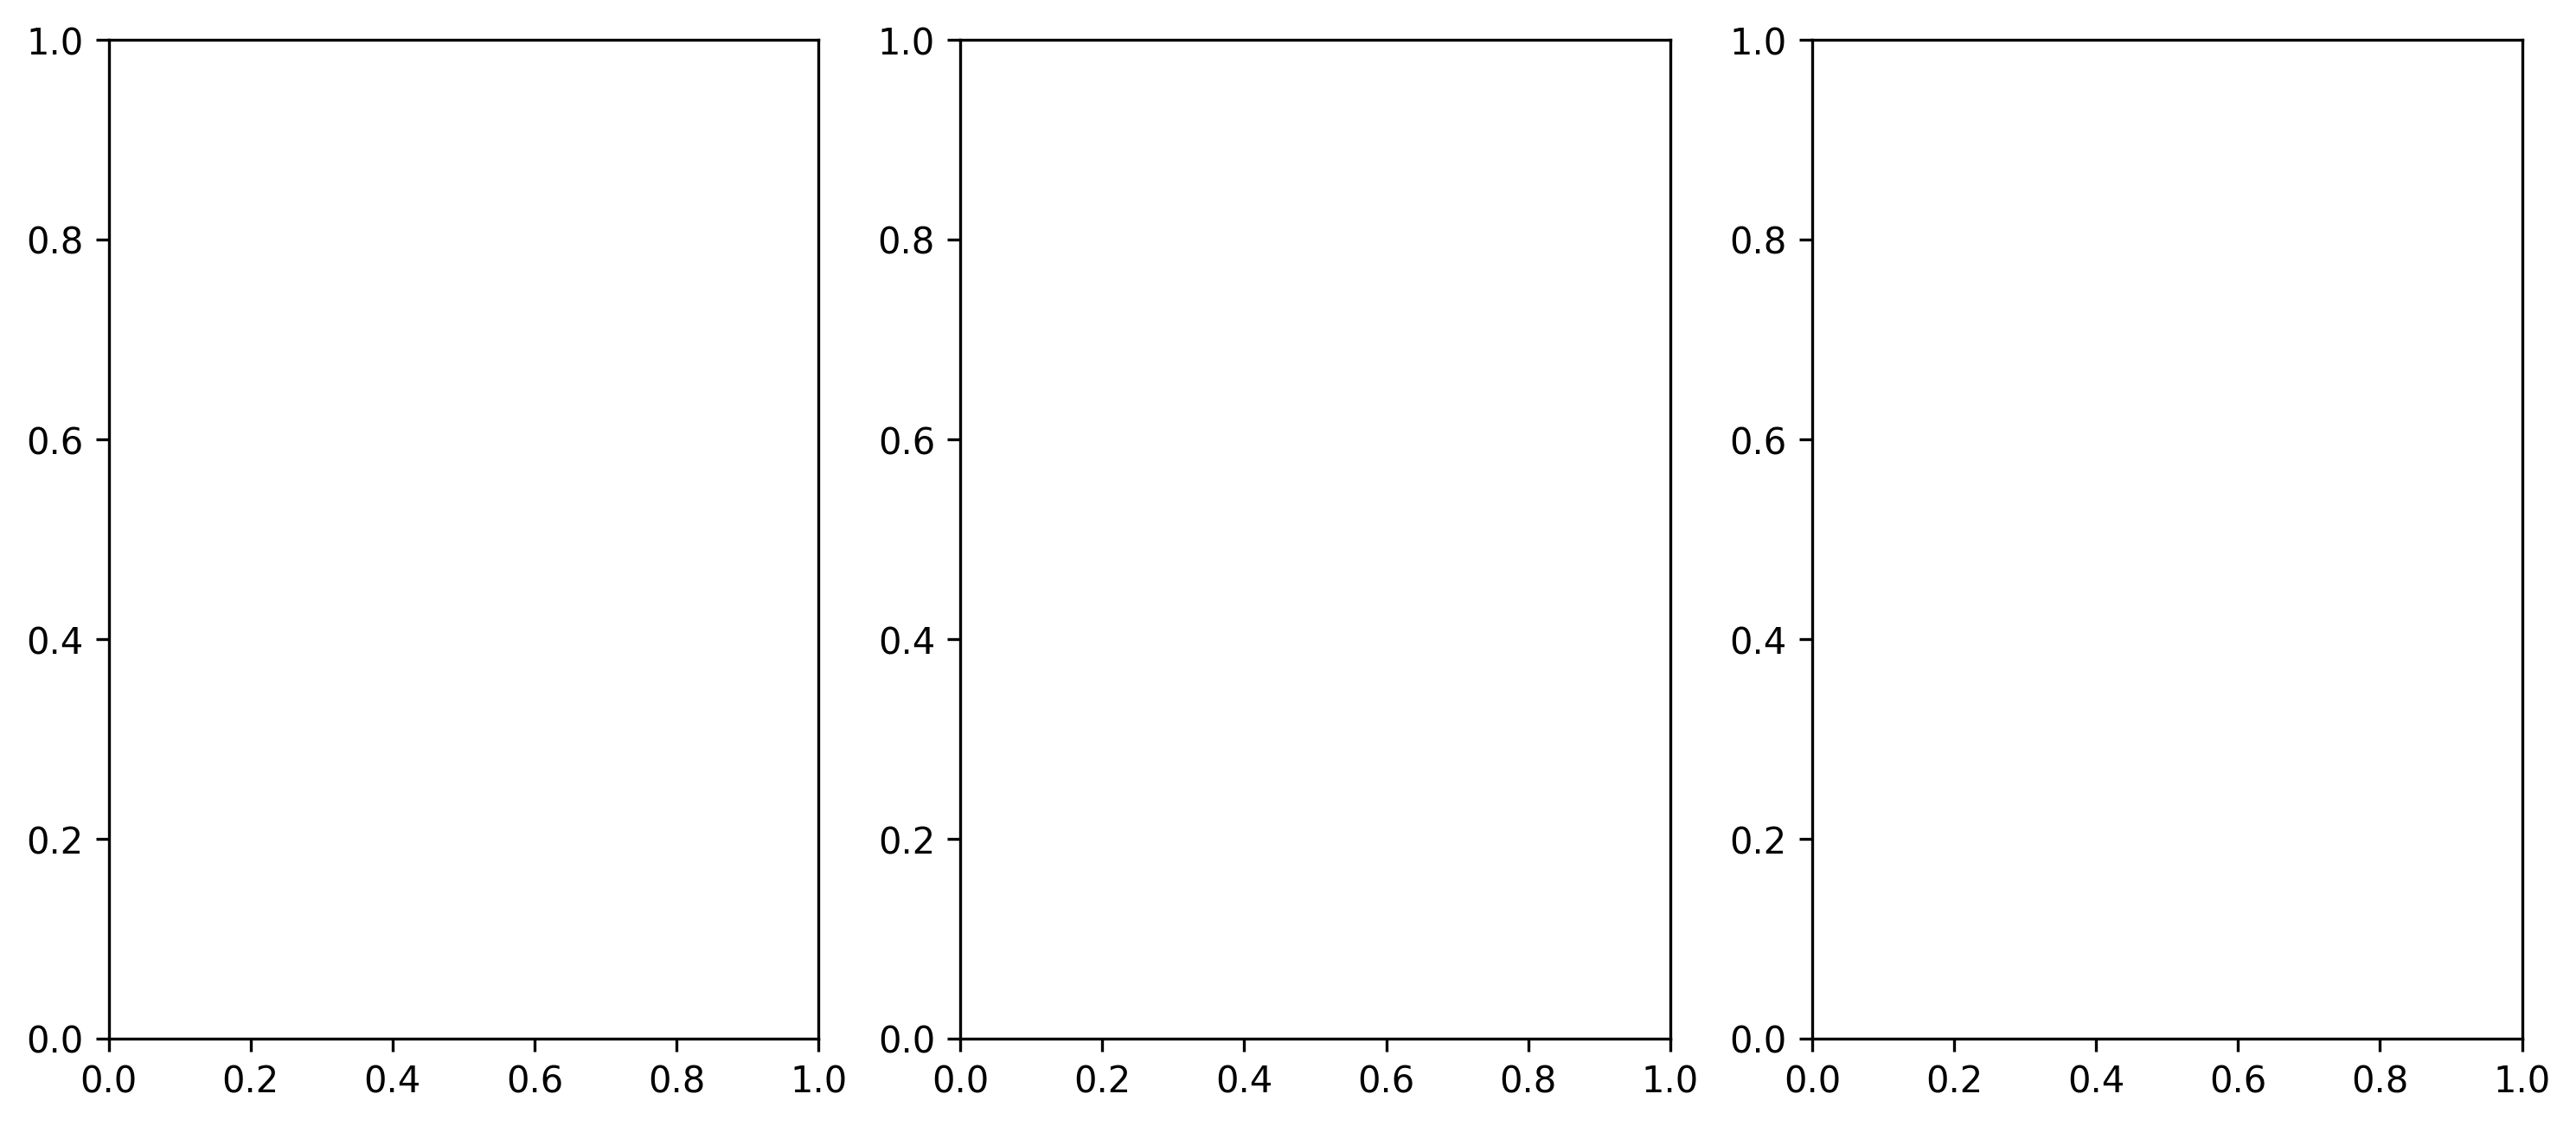

In [ ]:
fig, (ax1, ax2, ax3) = plt.subplots(1,3, figsize = (12,5), dpi = 300)
sns.barplot(data = df3, x = "KSegment", y = "Frequency", errorbar = None, hue = "Persona", ax = ax3)
ax3.set_title("Customer Frequency by Persona")

sns.barplot(data = df3, x = "KSegment", y = "TotalRevenue", estimator = 'sum', errorbar = None, hue = "Persona", ax = ax2)
ax2.set_title("Revenue Contribution by Segment, First 60 days")

sns.countplot(data = df3, y = "KSegment", hue = "Persona", ax = ax1)
ax1.set_title("Count of Customers by Persona ")
#plt.xticks(rotation = 90)
plt.tight_layout()
plt.show()

Analysing performance by assigned segment, for metrics registered in the first 60 days of data used for inferences:

- `Customer turnout` : `One-Time Acquaintance` had the highest turnout during the period of focus, accounting for more than 50% of all customers that showed up, followed by `Loyal Performers`, `One-Time Bulk-Buyers`, and `High-Value Elite` in last place.
- `Revenue` : `Loyal Performers` generated the highest revenue despite having a lower count than `One-Time Acquaintances`. This observation was driven by their higher frequency from repeat purchases, as well as their high `AvgUnitPrice`. This observation, along with those for the other segments, is consistent in ranking with what was seen during model development and exploratory data analysis of segments.
- `Frequency`: Consistent with segmentation insights, `High-Value Elite` customers registered the highest customer frequency, more than double that of `Loyal Performers`, who ranked second.

NameError: name 'df3' is not defined

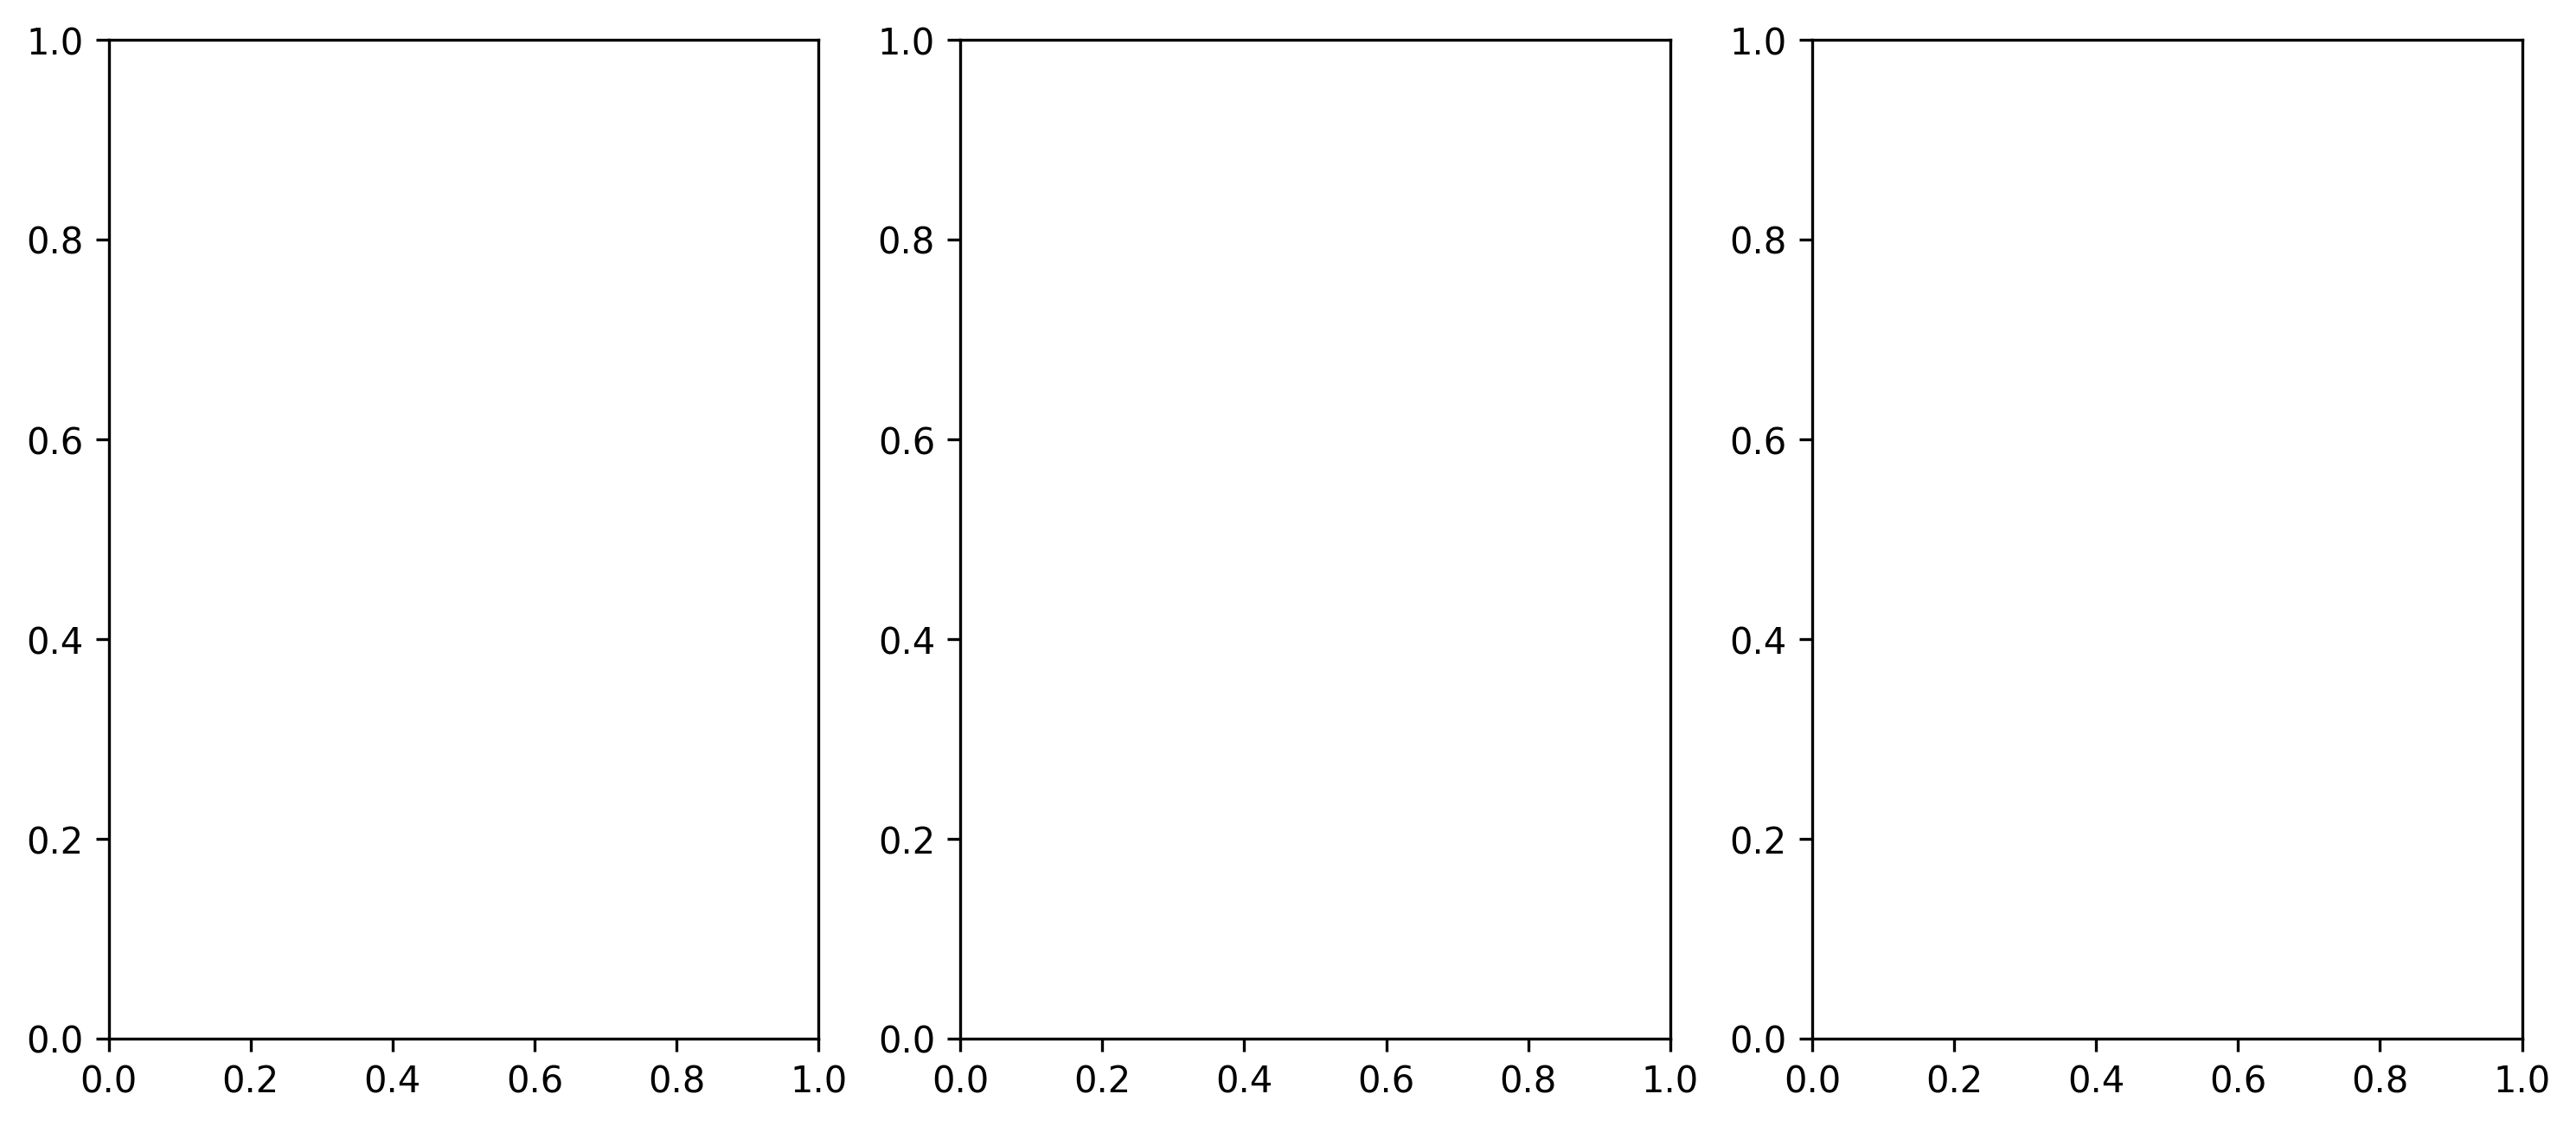

In [ ]:
fig, (ax1, ax2, ax3) = plt.subplots(1,3, figsize = (12,5), dpi = 300)
sns.boxplot(data = df3, x = "AOV", hue = "Persona", ax = ax3)
ax3.set_title("Average Order Value by Persona")

sns.boxplot(data = df3, x = "ProductDiversity", hue = "Persona", ax = ax2)
ax2.set_title("Product Diversity by Persona")

sns.boxplot(data = df3, x = "ObservedLifeSpan", hue = "Persona", ax = ax1)
ax1.set_title("Observed Lifespan by Persona")
#plt.xticks(rotation = 90)
plt.tight_layout()
plt.show()

Consistent with established characteristics during clustering, `High-Value Elite` customers exhibited the highest observed lifespan, and product diversity, followed by the `Loyal Performers`. On the other hand, `One-TimeBulk-Buyers` retained their high Average order value dominance.

### 4.0 ANALZING CHURN AND RISK PROFILING

#### 4.1 Churn Predictions by Segment

In [ ]:
plt.figure(figsize = (12,4), dpi = 300)
sns.countplot(data = df3, x = "Persona", hue = "ChurnLabel")
plt.title("Preview of Clients by Churn Status, Where 1 is for Churn")
plt.show()

NameError: name 'df3' is not defined

<Figure size 3600x1200 with 0 Axes>

As presented by the bar graph, almost all `One-Time Acquaintances` are expected to churn in the next 100 days after clocking a 60-day tenure with the business, having the highest expected churn rate. This was followed by `One-Time Bulk-Buyers`, while no `Loyal Performers` or `High-Value Elite` customers are expected to churn.

#### 4.2 Creating Risk Profile Based on Churn Probability and 100-Day CLTV

Churn Probability was split in half into two sections, with a midpoint set at 70%, with customers having a probability below 70% classed as `Low-Churn`, and those above classed as `High-Churn`.

On the other hand, 100-day CLTV was split as well, with a threshold at roughly $400, with those below classed as `Low-CLTV`, and those above as `High-CLTV`.

Combinations of the churn and CLTV risk classes were generated, creating `4 distinct risk profiles`, as presented below, with the two scatterplots comparing predicted churn probability with the 60-day revenue, and the predicted 100-day CLTV, to review how risk profiles compare in customer spend during observation and with expected future spend.

In [ ]:
churned_df["ChurnClass"] = pd.qcut(churned_df["ChurnProbability"], q = 2, labels = ["Low Churn", "High Churn"])
churned_df["CLTVClass"] = pd.qcut(churned_df["PredictedCLTV"], q = 2, labels = ["Low CLTV", "High CLTV"])
churned_df["RiskProfile"] = churned_df["ChurnClass"].astype("str") + '-' + churned_df["CLTVClass"].astype("str")
df3["RiskProfile"] = churned_df["ChurnClass"].astype("str") + '-' + churned_df["CLTVClass"].astype("str")

fig, (ax1, ax2) = plt.subplots(1,2, figsize = (12,4), dpi = 300)
sns.scatterplot(data = df3, x = 'ChurnProbability', y = 'TotalRevenue', hue = 'RiskProfile', ax = ax1)
ax1.set_title('First 60-day Tenure: Revenue vs Churn Probability')

sns.scatterplot(data = df3, x = 'ChurnProbability', y = 'PredictedCLTV', hue = 'RiskProfile', ax = ax2)
ax2.set_title('Predicted 100-day Revenue(CLTV) vs Churn Probability')
plt.tight_layout()
plt.show()

summary = churned_df.pivot_table(index = 'Persona', columns ='RiskProfile', values = 'CustomerID', aggfunc = 'count')

plt.figure(figsize = (12,2), dpi = 300)
sns.heatmap(data = summary, annot = True, fmt ='g', annot_kws = {'size': 15}, cmap = 'Reds')
plt.title('Count of Customers by Segment and Risk Profile')
plt.show()

NameError: name 'churned_df' is not defined

The risk profiles created on the 100-day predicted values, display similar separations in churn probability and spend, on data during the 60-day tenure, as presented by the scatterplots.

The most important risk profile of focus, considering the two segments predicted to churn are high-risk segments, is the `Low-Churn - High CLTV` risk profile (`customers with the lowest probability of churn and highest spend`), allowing the business to maximise return on re-acquisition efforts.

The risk profile of focus, with reference to the plots above, has a total of 88 `One-Time Acquaintances` and 12 `One-Time Bulk-Buyers`. It is characterised by customers with a churn probability of less than 70% who spent roughly more than `$400` during their observation tenure and are predicted to spend more than `$400` in the next 100-day window.

#### 5.0 RECOMMENDATION

In [ ]:
summary1 = df3.pivot_table(index = 'Persona', columns ='RiskProfile', values = 'TotalRevenue', aggfunc = 'sum')

summary1

plt.figure(figsize = (12,2), dpi = 300)
sns.heatmap(data = summary1, annot = True, fmt ='g', annot_kws = {'size': 15}, cmap = 'Greens')
plt.title('Revenue ($) Contributed in First 60 days Tenure by Segment and Risk Profile')
plt.show()

summary1 = churned_df.pivot_table(index = 'Persona', columns ='RiskProfile', values = 'PredictedCLTV', aggfunc = 'sum')

summary1

plt.figure(figsize = (12,2), dpi = 300)
sns.heatmap(data = summary1, annot = True, fmt ='g', annot_kws = {'size': 15}, cmap = 'Reds')
plt.title('Next 100-days, Revenue ($) (Predicted CLTV) at Risk by Segment and Risk Profile')
plt.show()

NameError: name 'df3' is not defined

The business should prioritize re-acquiring the `Low Churn - High CLTV` risk profile, while any efforts to re-engage the other risk profiles should be treated similarly to the efforts of acquiring a new customer who has never had contact with the business.

The business should aim for a `1:10 risk to reward ratio` in its re-acquisition efforts. That said, a total re-engagement budget of `$4,565` is proposed for `One-Time Acquaintances`, and `$740` for `One-Time Bulk-Buyers`.